In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
sys.path.append('..')
import hippocampalseq as hse
import hippocampalseq.preprocessing as hsep
import hippocampalseq.models as hsem 

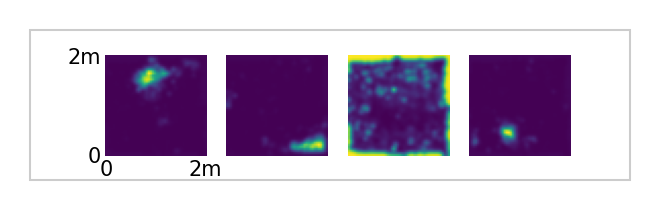

In [ ]:
rat_data = hsep.load_and_preprocess(os.path.realpath("../data"), "Harpy", 1)
hse.init_plotting()
hse.plot_placefields(rat_data.place_field_data.place_fields, [0,1,2,3])

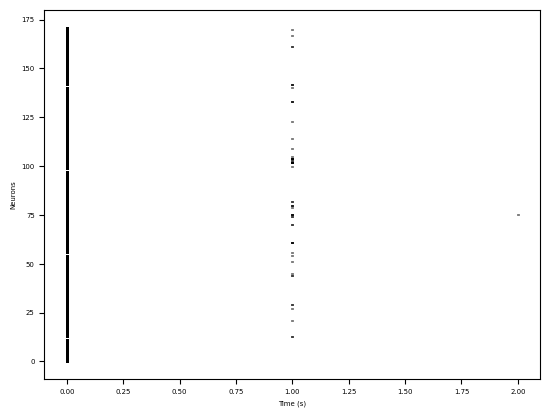

In [ ]:
hse.spike_raster_plot(rat_data.ripple_data.spikemats_ripple[67].T)

In [ ]:
m = hsem.Momentum(
        rat_data.place_field_data.place_fields[rat_data.place_field_data.place_cell_ids], 
        rat_data.ripple_data.spikemats_ripple[1],
        hsep.PFEIFFER_RECORDING_FPS, 
        (50, 50),
        seed=None
    )
fm = m.em(n_iter=100000, emtol=1e-3, lr=1.0, seed=None, gd_tol=1e-3)

torch.Size([35, 2]) torch.Size([35])
tensor(-0.0016) tensor(0.0024)
Converged after 670 epochs, exiting


tensor(35.8358) tensor(16.3786)
(tensor(34), tensor(1), tensor(0)) (tensor(2), tensor(0), tensor(0))


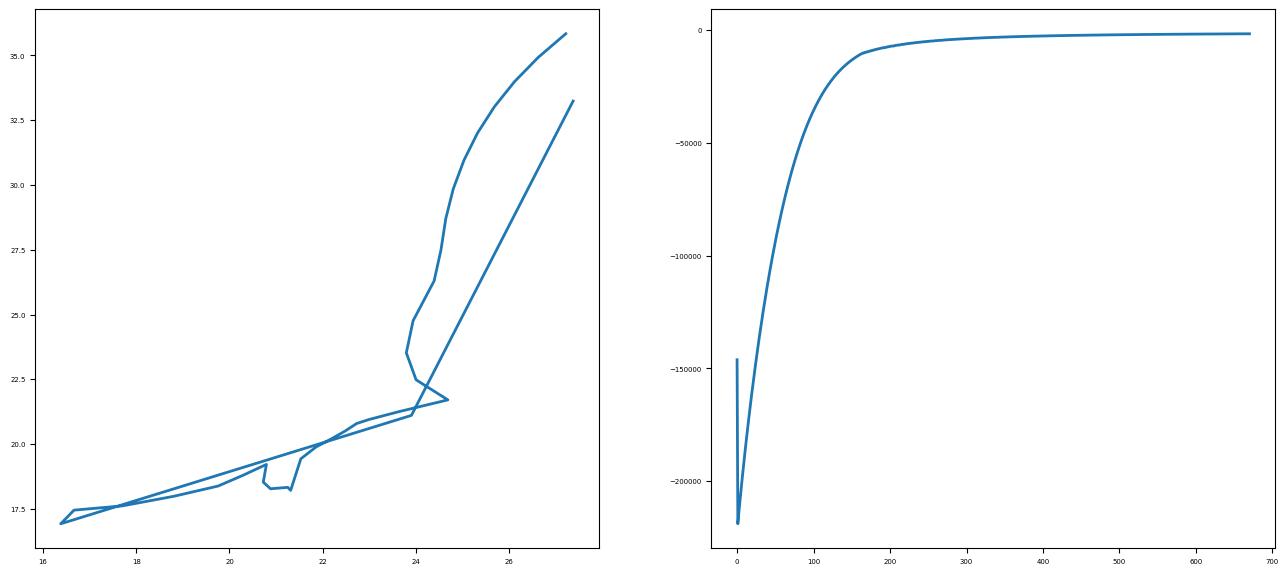

In [37]:
import torch
t = fm.smoothed_mean[:,:2]
plt.figure(figsize=(16,7))
plt.subplot(1,2,1)
plt.plot(t[:,0], t[:,1])
plt.subplot(1,2,2)
plt.plot(fm.negloglike)
print(t.max(), t.min())
print(
    torch.unravel_index(t.argmax(), t.shape),
    torch.unravel_index(t.argmin(), t.shape)
)

In [15]:
fm.smoothed_mean.shape, rat_data.ripple_data.spikemats_ripple[1].shape

(torch.Size([35, 4, 1]), (35, 169))

In [ ]:
from scipy.stats import multivariate_normal, norm
import ipywidgets as widgets
from ipywidgets import interact,fixed,interactive
import hippocampalseq.utils as hseu

def plot_emission_prob(ep, kl):
    dz = 1.0
    x = np.arange(ep.shape[1])
    y = np.arange(ep.shape[0])
    X,Y = np.meshgrid(x,y)

    pz = (ep / np.sum(ep)).reshape(X.shape)

    idxmax = np.unravel_index(np.argmax(pz), pz.shape)

    fig, ax = plt.subplots(2,2, figsize=(12,10))
    ax = ax.ravel()
    cs = ax[0].contourf(X, Y, pz, cmap='viridis')
    ax[0].scatter(idxmax[1], idxmax[0], s=1.0, c='red')
    ax[0].set_xlabel('X')
    ax[0].set_ylabel('Y')
    ax[0].set_title('Contour Plot of Emission Probability')
    fig.colorbar(cs)

    z = hseu.bin_points(x, y)
    #Ez,Vz,Zt = hseu.calc_normal_params(z, pz.ravel(), dz)
    Ez,Vz = hseu.laplacian_approximation(z, pz, kl)

    print(Ez)
    print(Vz)
    #print(Zt)

    ax[0].scatter(Ez[0], Ez[1], s=1.0, c='blue')

    mvn = multivariate_normal(mean=Ez, cov=Vz)
    Z = mvn.pdf(np.column_stack((X.ravel(), Y.ravel())))
    Z = Z.reshape(X.shape) / np.sum(Z)

    cs1 = ax[1].contourf(X,Y,Z, cmap='viridis')
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('Y')
    ax[1].set_title('Contour Plot of Gaussian Approximating Poisson Emission')
    fig.colorbar(cs1)

    marginal_x = np.sum(pz, axis=0)
    #Ez,Vz,_ = hseu.calc_normal_params(x[:,None], marginal_x, dz)
    Ez,Vz = hseu.laplacian_approximation(x, marginal_x, kl)
    Px = norm(Ez, Vz).pdf(x)
    Px /= np.sum(Px)
    print(Ez)
    print(Vz)
   
    ax[2].plot(marginal_x)
    ax[2].plot(Px.ravel(), c='orange')
    ax[2].set_title('Marginal Distribution Over X')

    marginal_y = np.sum(pz, axis=1)
    #Ez,Vz,Zt = hseu.calc_normal_params(y[:,None], marginal_y, dz)
    Ez,Vz = hseu.laplacian_approximation(y, marginal_y, kl)
    Py = norm(Ez, Vz).pdf(y) 
    Py /= np.sum(Py)
    print(Ez)
    print(Vz)



    ax[3].plot(marginal_y)
    ax[3].plot(Py.ravel(), c='orange')
    ax[3].set_title('Marginal Distribution over Y')

def display_likelihood(n, t, kl):
    ek = hseu.calc_poisson_emission_probabilities_2d(
        rat_data.ripple_data.spikemats_ripple[n],
        rat_data.place_field_data.place_fields[rat_data.place_field_data.place_cell_ids],
        hsep.PFEIFFER_RECORDING_FPS
    )
    plot_emission_prob(ek[t], kl)

c1 = widgets.IntSlider(
    value=0, 
    min=0, 
    max=len(rat_data.ripple_data.spikemats_ripple),
    continuous_update=False
)
c2 = widgets.IntSlider(
    value=0, 
    min=0, 
    max=1,
    continuous_update=False
)
kl = widgets.Dropdown(
    options=['pq', 'qp'],
    descripion="KL-divergence"
)

def update_slider(x):
    c2.max = len(rat_data.ripple_data.spikemats_ripple[c1.value])

c1.observe(update_slider)

i_control = interactive(display_likelihood, n=c1, t=c2, kl=kl)
i_control
